In [1]:
import os
import pandas as pd
import numpy as np
import time

from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.api import VAR
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import shap

import matplotlib.pyplot as plt
import traceback
import psutil as ps
import warnings
warnings.filterwarnings("ignore")

In [2]:
%run "C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/src/models/train_models.py"
%run "C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/src/models/fine_tune_models.py"
%run "C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/src/models/predict_models.py"

In [3]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline")
from src.models import train_models
from src.models import fine_tune_models
from src.models import predict_models

In [4]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/data/processed")
weather_data = pd.read_csv("clean_weather_data.csv", parse_dates = ["Date"])
weather_data.head()

,Date,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,...,Rolling std of Surface_pressure,Rolling std of Pressure_msl,Day_of-year,Sine_Day_of-year,Cose_Day_of-year,day_of_week,day_of_month,month,quarter,is_weekend
0,2020-01-01 23:00:00,10.3,95,0.0,11.7,17.0,1007.0,1021.7,0,11.629167,...,1.337252,1.297482,1,0.017213,0.999852,2,1,1,1,0
1,2020-01-02 00:00:00,10.8,94,0.0,11.4,20.0,1006.7,1021.3,0,11.837500,...,1.299770,1.275948,2,0.034422,0.999407,3,2,1,1,0
2,2020-01-02 01:00:00,10.4,95,0.0,11.2,18.4,1006.3,1020.9,0,12.033333,...,1.244437,1.239536,2,0.034422,0.999407,3,2,1,1,0
3,2020-01-02 02:00:00,10.3,95,0.0,11.0,18.9,1006.2,1020.8,0,12.212500,...,1.194523,1.203618,2,0.034422,0.999407,3,2,1,1,0
4,2020-01-02 03:00:00,9.8,96,0.0,10.8,18.1,1005.6,1020.3,0,12.379167,...,1.148913,1.175351,2,0.034422,0.999407,3,2,1,1,0


In [5]:
cpu_percent = ps.cpu_percent(interval=1)
print(f"CPU Usage: {cpu_percent}%")

CPU Usage: 33.5%


In [6]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52585 entries, 0 to 52584
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Date                               52585 non-null  datetime64[ns]
 1   Temperature                        52585 non-null  float64       
 2   Relative_humidity                  52585 non-null  int64         
 3   Rain                               52585 non-null  float64       
 4   Soil_temperature                   52585 non-null  float64       
 5   Wind_speed                         52585 non-null  float64       
 6   Surface_pressure                   52585 non-null  float64       
 7   Pressure_msl                       52585 non-null  float64       
 8   is_day                             52585 non-null  int64         
 9   Rolling Mean of Temperature        52585 non-null  float64       
 10  Rolling Mean of Relative_humidity 

### 1) Vector Autoregression (VAR)

In [7]:
weather_data.set_index("Date",inplace = True)

In [8]:
rm_cols = [col for col in weather_data.columns if "std" or "is_" in col]
weather_data.drop(columns=rm_cols)

""
Date
2020-01-01 23:00:00
2020-01-02 00:00:00
2020-01-02 01:00:00
2020-01-02 02:00:00
2020-01-02 03:00:00
...
2025-12-31 19:00:00
2025-12-31 20:00:00
2025-12-31 21:00:00


In [9]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52585 entries, 2020-01-01 23:00:00 to 2025-12-31 23:00:00
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Temperature                        52585 non-null  float64
 1   Relative_humidity                  52585 non-null  int64  
 2   Rain                               52585 non-null  float64
 3   Soil_temperature                   52585 non-null  float64
 4   Wind_speed                         52585 non-null  float64
 5   Surface_pressure                   52585 non-null  float64
 6   Pressure_msl                       52585 non-null  float64
 7   is_day                             52585 non-null  int64  
 8   Rolling Mean of Temperature        52585 non-null  float64
 9   Rolling Mean of Relative_humidity  52585 non-null  float64
 10  Rolling Mean of Rain               52585 non-null  float64
 11  Rolling Mean of Soi

#### Causality Test with Granger Causality Test

In [10]:
#test Granger Causality Test for each time series
def causality_test(data):
    max_lag = 24
    
    result = grangercausalitytests(data, maxlag = max_lag, verbose = True)
    for lag in range(1, max_lag+1):
        p_value = result[lag][0]["ssr_ftest"][1]
        print(f"lag {lag : 2d}: P Value = {p_value : .5f}")
        
    alpha = 0.05

    for lag in range(1, max_lag + 1):
        p_value = result[lag][0]['ssr_ftest'][1]

        if p_value < alpha:
            print(f"Lag {lag}: Significant (p = {p_value:.5f})")
        else:
            print(f"Lag {lag}: Not Significant (p = {p_value:.5f})")

In [11]:
causality_test(weather_data[["Temperature", "Relative_humidity"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=651.9582, p=0.0000  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=651.9953, p=0.0000  , df=1
likelihood ratio test: chi2=647.9864, p=0.0000  , df=1
parameter F test:         F=651.9582, p=0.0000  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=810.3506, p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=1620.8553, p=0.0000  , df=2
likelihood ratio test: chi2=1596.3758, p=0.0000  , df=2
parameter F test:         F=810.3506, p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=837.2655, p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=2512.1309, p=0.0000  , df=3
likelihood ratio test: chi2=2453.9671, p=0.0000  , df=3
parameter F test:         F=837.2655, p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=648.

In [12]:
causality_test(weather_data[["Temperature", "Rain"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.3417  , p=0.2467  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=1.3418  , p=0.2467  , df=1
likelihood ratio test: chi2=1.3418  , p=0.2467  , df=1
parameter F test:         F=1.3417  , p=0.2467  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=327.0312, p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=654.1246, p=0.0000  , df=2
likelihood ratio test: chi2=650.0894, p=0.0000  , df=2
parameter F test:         F=327.0312, p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=196.6525, p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=590.0361, p=0.0000  , df=3
likelihood ratio test: chi2=586.7502, p=0.0000  , df=3
parameter F test:         F=196.6525, p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=150.2150

In [13]:
causality_test(weather_data[["Temperature", "Soil_temperature"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=4113.0903, p=0.0000  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=4113.3250, p=0.0000  , df=1
likelihood ratio test: chi2=3960.3714, p=0.0000  , df=1
parameter F test:         F=4113.0903, p=0.0000  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2277.8607, p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=4556.1547, p=0.0000  , df=2
likelihood ratio test: chi2=4369.4754, p=0.0000  , df=2
parameter F test:         F=2277.8607, p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1707.8438, p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=5124.2136, p=0.0000  , df=3
likelihood ratio test: chi2=4889.6528, p=0.0000  , df=3
parameter F test:         F=1707.8438, p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:       

In [14]:
causality_test(weather_data[["Temperature", "Wind_speed"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=733.2341, p=0.0000  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=733.2759, p=0.0000  , df=1
likelihood ratio test: chi2=728.2102, p=0.0000  , df=1
parameter F test:         F=733.2341, p=0.0000  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=18.6406 , p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=37.2848 , p=0.0000  , df=2
likelihood ratio test: chi2=37.2716 , p=0.0000  , df=2
parameter F test:         F=18.6406 , p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=41.6232 , p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=124.8861, p=0.0000  , df=3
likelihood ratio test: chi2=124.7380, p=0.0000  , df=3
parameter F test:         F=41.6232 , p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=58.5481 

In [15]:
causality_test(weather_data[["Temperature", "Surface_pressure"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=498.8146, p=0.0000  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=498.8430, p=0.0000  , df=1
likelihood ratio test: chi2=496.4917, p=0.0000  , df=1
parameter F test:         F=498.8146, p=0.0000  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1935.0945, p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=3870.5570, p=0.0000  , df=2
likelihood ratio test: chi2=3734.7300, p=0.0000  , df=2
parameter F test:         F=1935.0945, p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2283.0021, p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=6849.9182, p=0.0000  , df=3
likelihood ratio test: chi2=6439.0639, p=0.0000  , df=3
parameter F test:         F=2283.0021, p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=

In [16]:
causality_test(weather_data[["Temperature", "Pressure_msl"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=498.2695, p=0.0000  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=498.2979, p=0.0000  , df=1
likelihood ratio test: chi2=495.9517, p=0.0000  , df=1
parameter F test:         F=498.2695, p=0.0000  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1944.1009, p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=3888.5716, p=0.0000  , df=2
likelihood ratio test: chi2=3751.5068, p=0.0000  , df=2
parameter F test:         F=1944.1009, p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2283.8195, p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=6852.3707, p=0.0000  , df=3
likelihood ratio test: chi2=6441.2337, p=0.0000  , df=3
parameter F test:         F=2283.8195, p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=

In [17]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52585 entries, 2020-01-01 23:00:00 to 2025-12-31 23:00:00
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Temperature                        52585 non-null  float64
 1   Relative_humidity                  52585 non-null  int64  
 2   Rain                               52585 non-null  float64
 3   Soil_temperature                   52585 non-null  float64
 4   Wind_speed                         52585 non-null  float64
 5   Surface_pressure                   52585 non-null  float64
 6   Pressure_msl                       52585 non-null  float64
 7   is_day                             52585 non-null  int64  
 8   Rolling Mean of Temperature        52585 non-null  float64
 9   Rolling Mean of Relative_humidity  52585 non-null  float64
 10  Rolling Mean of Rain               52585 non-null  float64
 11  Rolling Mean of Soi

- **except Lag 1: Not Significant (p = 0.24673) of Rain feature with Temperature, other are good relationship with Temperature series.**
- **but we also take Rain for modeling**

In [18]:
#spliting time series into train and test sets
weather_data_ = weather_data.loc[:,"Temperature":"is_day"]
train_data = weather_data_[:int(0.9*len(weather_data_))]
test_data = weather_data_[int(0.9*len(weather_data_)):]

In [19]:
train_data.shape

(47326, 8)

In [20]:
test_data.shape

(5259, 8)

In [21]:
#train models on train_data
var_model = VAR(train_data)

In [22]:
lag_order = var_model.select_order(maxlags = 20)
lag_order.summary()

,AIC,BIC,FPE,HQIC
0,7.864,7.865,2602.,7.864
1,-8.826,-8.813,0.0001469,-8.822
2,-10.53,-10.51,2.664e-05,-10.53
3,-10.84,-10.80,1.962e-05,-10.83
4,-11.06,-11.01,1.579e-05,-11.04
5,-11.23,-11.17,1.321e-05,-11.22
6,-11.37,-11.30,1.150e-05,-11.35
7,-11.48,-11.40,1.031e-05,-11.46
8,-11.56,-11.47,9.499e-06,-11.53
9,-11.65,-11.54,8.708e-06,-11.62


- **take 20 as a optimal or good maxlags value for var model.**

In [23]:
model_result = var_model.fit(maxlags = 20)
model_result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 12, Jul, 2026
Time:                     17:43:12
--------------------------------------------------------------------
No. of Equations:         8.00000    BIC:                   -12.3920
Nobs:                     47306.0    HQIC:                  -12.5557
Log likelihood:          -236953.    FPE:                3.27020e-06
AIC:                     -12.6307    Det(Omega_mle):     3.18251e-06
--------------------------------------------------------------------
Results for equation Temperature
                           coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------
const                        10.371636         1.461496            7.097           0.000
L1.Temperature                1.020109         0.008816          115.710           0.000
L1.Relative_humidity  

In [24]:
cpu_percent = ps.cpu_percent(interval=1)
print(f"CPU Usage: {cpu_percent}%")

CPU Usage: 52.1%


In [25]:
#forcasting or predicting futures 	Temperature	Relative_humidity	Rain	Soil_temperature	Wind_speed	Surface_pressure	Pressure_msl	is_day
forecast = model_result.forecast(
    y=train_data.values[-20:],
    steps=len(test_data)
)

In [26]:
forecast_df = pd.DataFrame(
    forecast,
    index=test_data.index,
    columns=test_data.columns
)

forecast_df.head(5)

,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day
Date,,,,,,,,
2025-05-26 21:00:00,30.989957,60.868927,0.039925,31.962393,21.370416,986.383135,999.743255,0.053371
2025-05-26 22:00:00,30.572908,63.019008,0.024335,31.474442,21.490600,986.659061,1000.044432,-0.025645
2025-05-26 23:00:00,30.212820,65.135496,0.092775,31.079140,21.175414,986.690990,1000.094449,-0.065030
2025-05-27 00:00:00,29.754857,67.349042,0.237442,30.745525,21.181963,986.473826,999.898037,-0.054817
2025-05-27 01:00:00,29.188763,69.615661,0.253232,30.431224,21.402449,986.092352,999.543387,-0.101442


In [27]:
mae = mean_absolute_error(
    test_data["Temperature"],
    forecast_df["Temperature"]
)

rmse = np.sqrt(
    mean_squared_error(
        test_data["Temperature"],
        forecast_df["Temperature"]
    )
)

r2 = r2_score(
    test_data["Temperature"],
    forecast_df["Temperature"]
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 4.034843584316283
RMSE: 5.957982782263815
R²  : 0.18366943047934914


- **clearly see var gives very low error values and good performance.**
- **Comparet to ARIMA & SARIMA Models VAR gives good resutls**

In [28]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/reports/figures")
def actuva_vs_predicted(feature):
    plt.figure(figsize=(12, 5))
    plt.plot(test_data.index, test_data[feature], label="Actual")
    plt.plot(test_data.index, forecast_df[feature], label="Forecast")

    plt.title(f"{feature}: Actual vs Forecast")
    plt.xlabel("Time")
    plt.ylabel(feature)
    plt.legend()
    plt.savefig(f"{feature}_Actual_vs_Pred(VAR).png")

    plt.show()

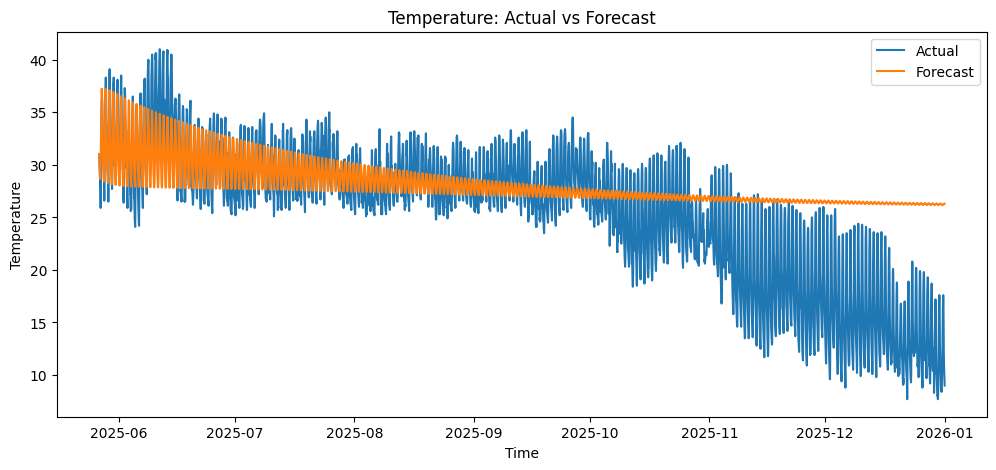

In [29]:
actuva_vs_predicted("Temperature")

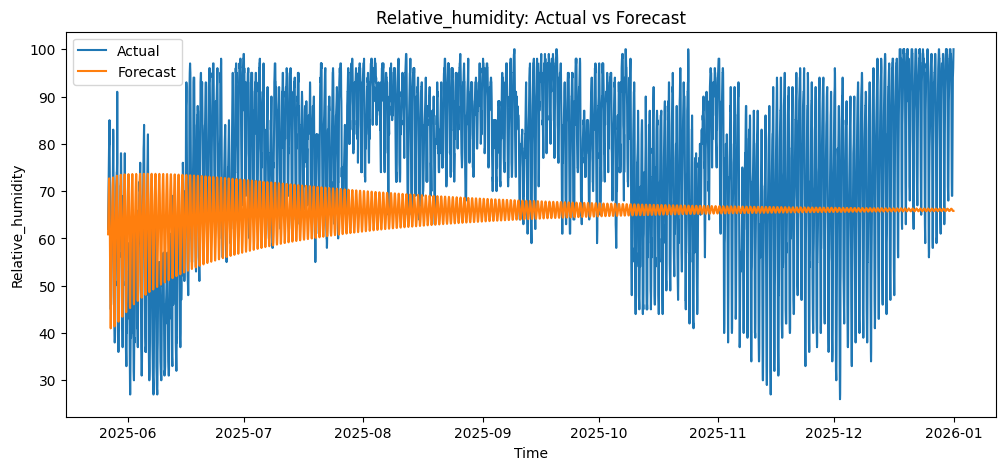

In [30]:
actuva_vs_predicted("Relative_humidity")

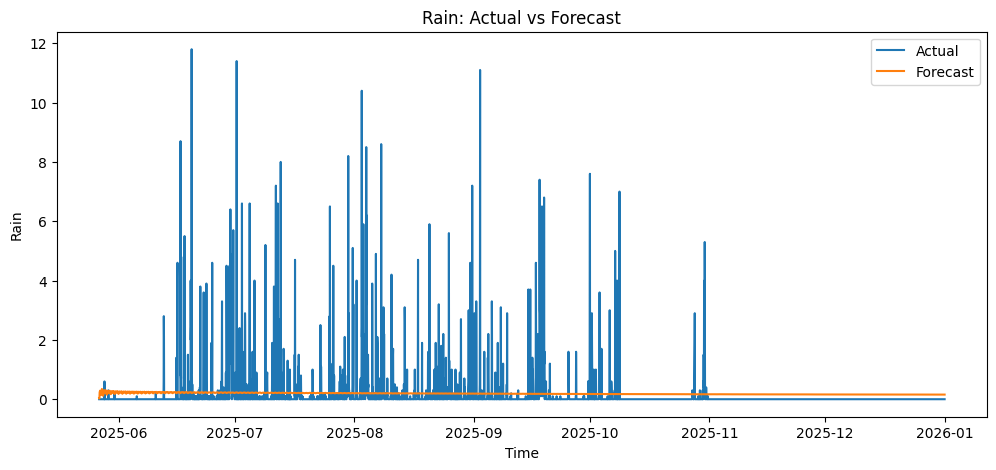

In [31]:
actuva_vs_predicted("Rain")

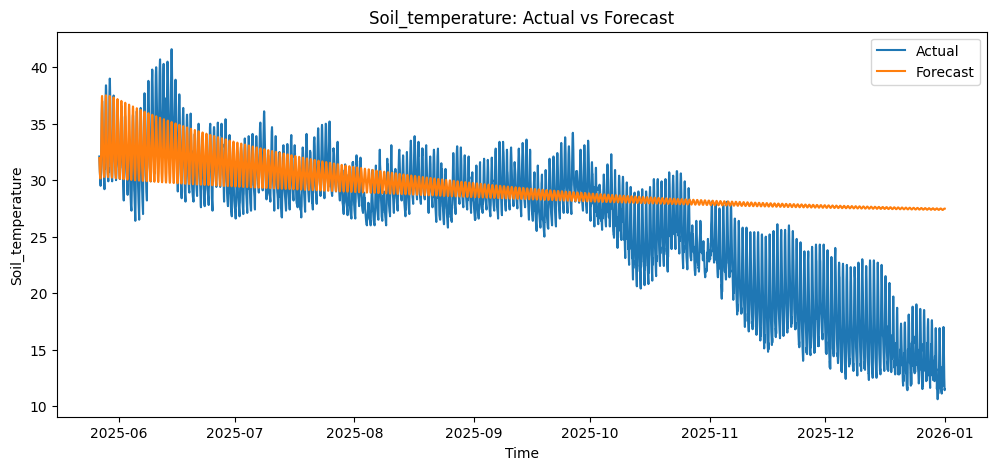

In [32]:
actuva_vs_predicted("Soil_temperature")

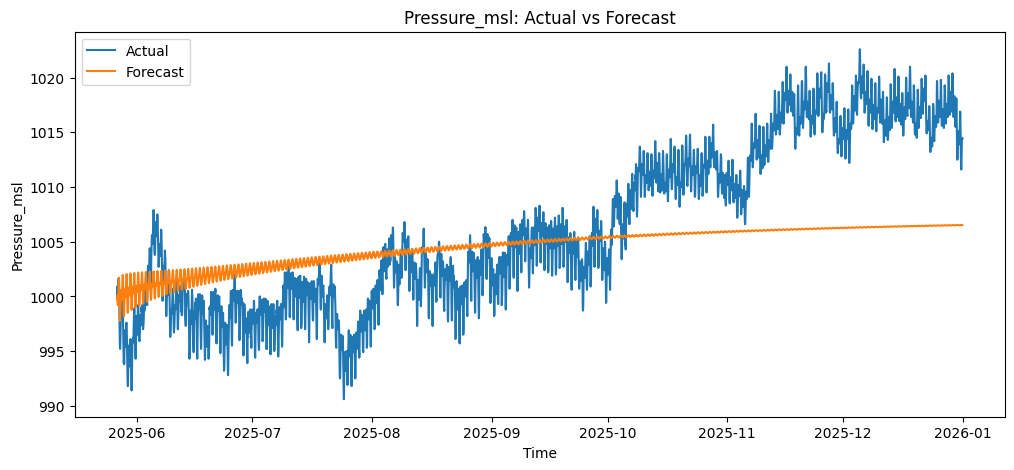

In [33]:
actuva_vs_predicted("Pressure_msl")

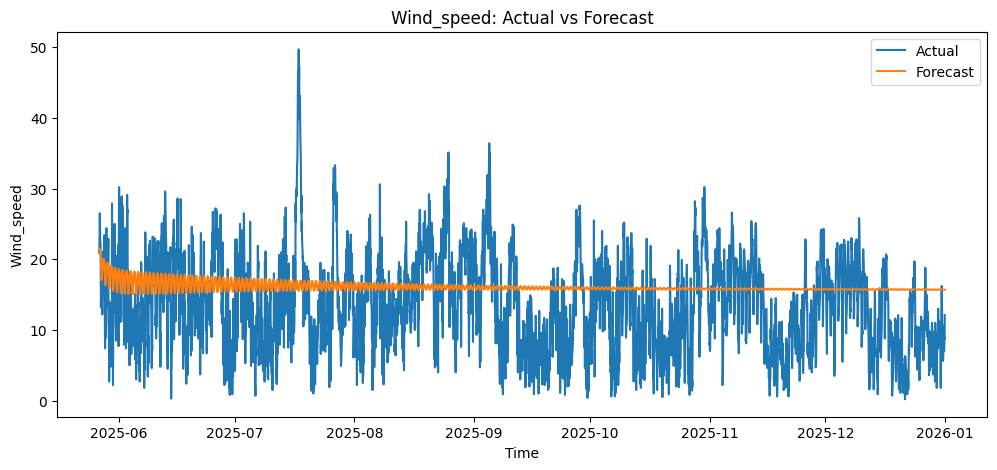

In [34]:
actuva_vs_predicted("Wind_speed")

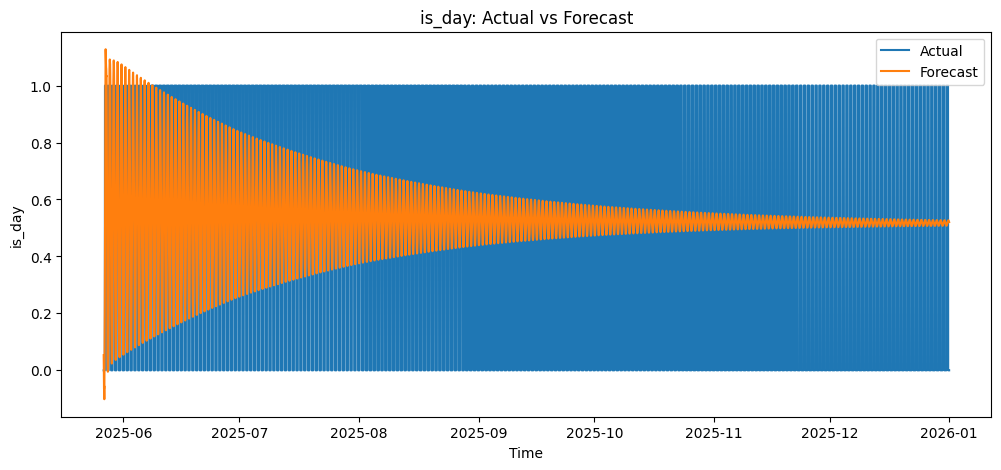

In [35]:
actuva_vs_predicted("is_day")

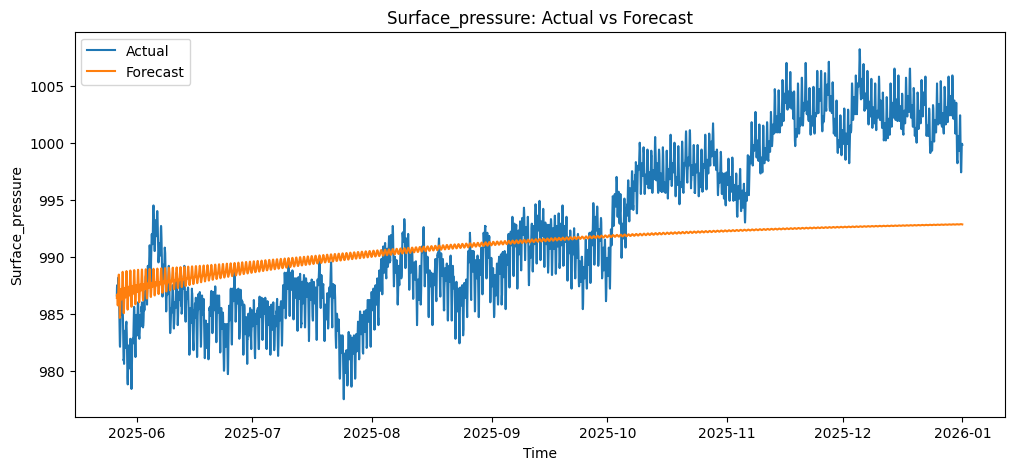

In [36]:
actuva_vs_predicted("Surface_pressure")

### XGBRegressor Model

In [37]:
train_data = weather_data[:int(0.9*len(weather_data))]
test_data = weather_data[int(0.9*len(weather_data)):]

In [38]:
train_data.shape

(47326, 30)

In [39]:
train_data.columns

Index(['Temperature', 'Relative_humidity', 'Rain', 'Soil_temperature',
       'Wind_speed', 'Surface_pressure', 'Pressure_msl', 'is_day',
       'Rolling Mean of Temperature', 'Rolling Mean of Relative_humidity',
       'Rolling Mean of Rain', 'Rolling Mean of Soil_temperature',
       'Rolling Mean of Wind_speed', 'Rolling Mean of Surface_pressure',
       'Rolling Mean of Pressure_msl', 'Rolling std of Temperature',
       'Rolling std of Relative_humidity', 'Rolling std of Rain',
       'Rolling std of Soil_temperature', 'Rolling std of Wind_speed',
       'Rolling std of Surface_pressure', 'Rolling std of Pressure_msl',
       'Day_of-year', 'Sine_Day_of-year', 'Cose_Day_of-year', 'day_of_week',
       'day_of_month', 'month', 'quarter', 'is_weekend'],
      dtype='object')

In [40]:
test_data.shape

(5259, 30)

In [41]:
#train model
results,input_features = train_models.xgbmodel(weather_data,train_data,test_data)

In [42]:
cpu_percent = ps.cpu_percent(interval=1)
print(f"CPU Usage: {cpu_percent}%")

CPU Usage: 75.3%


In [43]:
results

,Target,MAE,RMSE,R²,Filename
0,Temperature,0.527159,0.701469,0.988684,Temperature_xgb_model.pkl
1,Relative_humidity,2.826380,3.735067,0.952381,Relative_humidity_xgb_model.pkl
2,Rain,0.267986,0.753356,0.029953,Rain_xgb_model.pkl
3,Soil_temperature,0.486246,0.636077,0.989326,Soil_temperature_xgb_model.pkl
4,Wind_speed,3.310978,4.208739,0.600560,Wind_speed_xgb_model.pkl
5,Surface_pressure,0.028385,0.082240,0.999867,Surface_pressure_xgb_model.pkl
6,Pressure_msl,0.028520,0.081497,0.999881,Pressure_msl_xgb_model.pkl
7,is_day,0.208402,0.298260,0.644038,is_day_xgb_model.pkl


- **almost all models give low error values except Rain r2 value**
- **To ovetcome this some short of disadvantages, we need to finetune to increase the performance of the models.**

In [44]:
input_features

Index(['Temperature', 'Relative_humidity', 'Rain', 'Soil_temperature',
       'Wind_speed', 'Surface_pressure', 'Pressure_msl',
       'Rolling Mean of Temperature', 'Rolling Mean of Relative_humidity',
       'Rolling Mean of Rain', 'Rolling Mean of Soil_temperature',
       'Rolling Mean of Wind_speed', 'Rolling Mean of Surface_pressure',
       'Rolling Mean of Pressure_msl', 'Rolling std of Temperature',
       'Rolling std of Relative_humidity', 'Rolling std of Rain',
       'Rolling std of Soil_temperature', 'Rolling std of Wind_speed',
       'Rolling std of Surface_pressure', 'Rolling std of Pressure_msl',
       'Day_of-year', 'Sine_Day_of-year', 'Cose_Day_of-year', 'day_of_week',
       'day_of_month', 'month', 'quarter', 'is_weekend'],
      dtype='object')

In [45]:
len(input_features)

29

In [46]:
#fine_tune_models.finetune_model(weather_data,train_data,test_data)

In [47]:
#take some sample data to predict future temperature of the delhi
new_data = [
    69,
    0,
    16.8,
    6.6,
    998.1,
    1012.3,
    1,
    11.92916667,
    90.41666667,
    0,
    13.1125,
    8.866666667,
    1000.020833,
    1014.491667,
    3.132783061,
    11.39762243,
    0,
    1.925416386,
    3.657590876,
    1.206496605,
    1.280596555,
    365,
    6.43E-16,
    1,
    2,
    31,
    12,
    4,
    0
]

new_data = np.array(new_data).reshape(1, -1)

In [48]:
result = predict_models.forcast(new_data,"Temperature")
result

array([16.866724], dtype=float32)

### Evaluation & Interpretation(SHAP) of the Models

In [49]:
def evaluate_model(target):
    os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models")
    X_train = train_data.drop(columns=[target])
    y_train = train_data[target]

    X_test = test_data.drop(columns=[target])
    y_test = test_data[target]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    with open(f'fine_{target}_xgb_model.pkl', 'rb') as file:
        loaded_model = pickle.load(file)

    y_pred = loaded_model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    

    return y_pred,y_test,mae,rmse,r2,loaded_model,X_train,target,X_test



##### Temperature

In [50]:
def plot_Actual_vs_Predicted(feature):
    y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model(feature)
    os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/reports/figures")
    plt.figure(figsize=(15,5))
    plt.plot(y_test.values, label="Actual", linewidth=2)
    plt.plot(y_pred, label="Predicted", linewidth=2)
    plt.xlabel("Time")
    plt.ylabel(feature)
    plt.title(f"Actual vs Predicted [R2: {round(r2,2)}]")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{feature}_Actual_vs_Pred(XGB).png", dpi=300, bbox_inches="tight")
    plt.show()

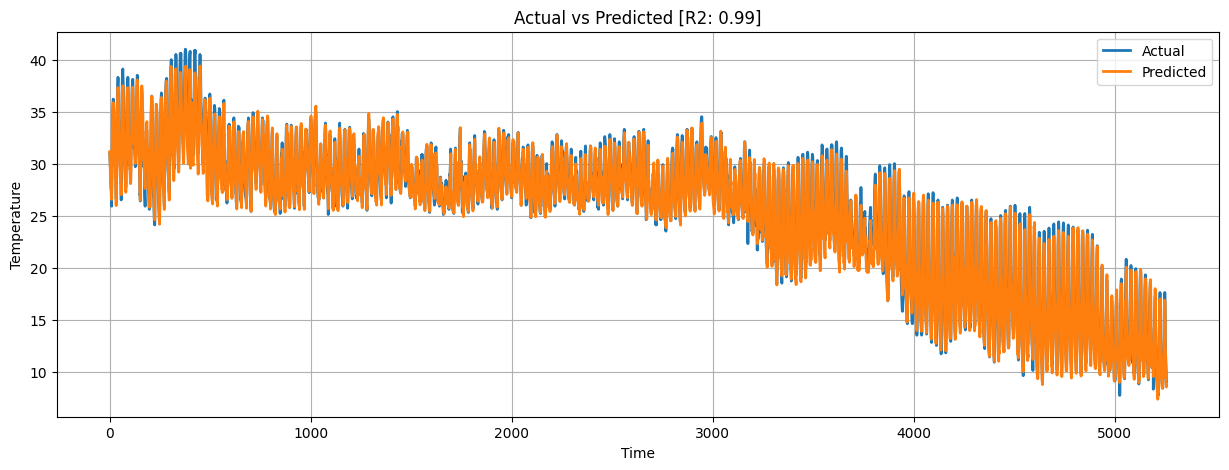

In [51]:
plot_Actual_vs_Predicted("Temperature")

In [52]:
def summary(feature):
    y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model(feature)
    
    params = pd.DataFrame([model.get_params()])

    importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": model.feature_importances_
    })

    eval_df = pd.DataFrame({
        "Metric": ["MAE", "RMSE", "R2"],
        "Value": [mae, rmse, r2]
    })

    merged = pd.concat([params, importance, eval_df], ignore_index=True)

    os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models/model_summaries")
    merged.to_excel(f"{target} Model Summary.xlsx",index = False)

In [53]:
summary("Temperature")

In [54]:
def model_interpretation(feature):
    y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model(feature)
    explainer = shap.Explainer(model)
    shap_values = explainer(X_test)

    shap.summary_plot(shap_values,X_test,plot_type = "bar",show=False)
    os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/reports/figures")
    plt.tight_layout()
    plt.savefig(f"{target}_shap_summary.png", dpi=300, bbox_inches="tight")
    plt.show()

In [55]:
cpu_percent = ps.cpu_percent(interval=1)
print(f"CPU Usage: {cpu_percent}%")

CPU Usage: 49.3%


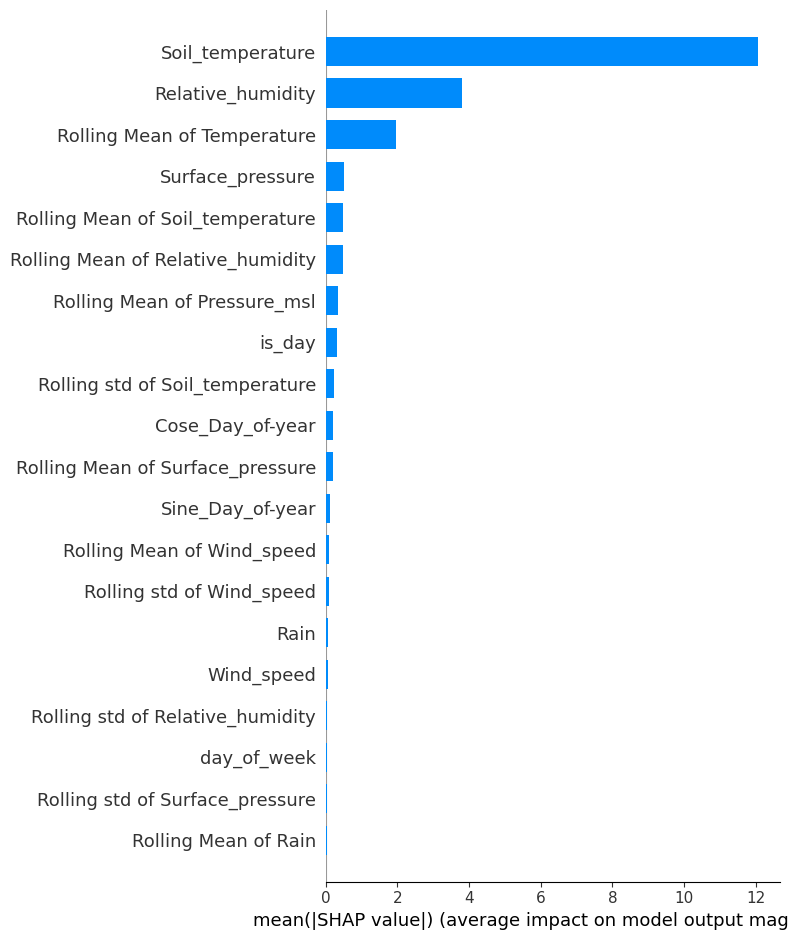

In [56]:
model_interpretation("Temperature")

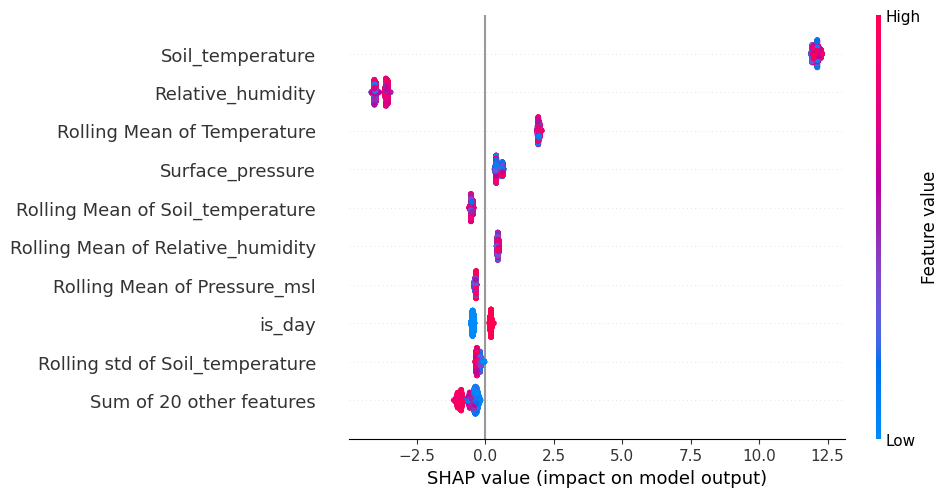

In [57]:
y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model("Temperature")
explainer = shap.Explainer(model)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

In [58]:
#shap.plots.heatmap(shap_values)

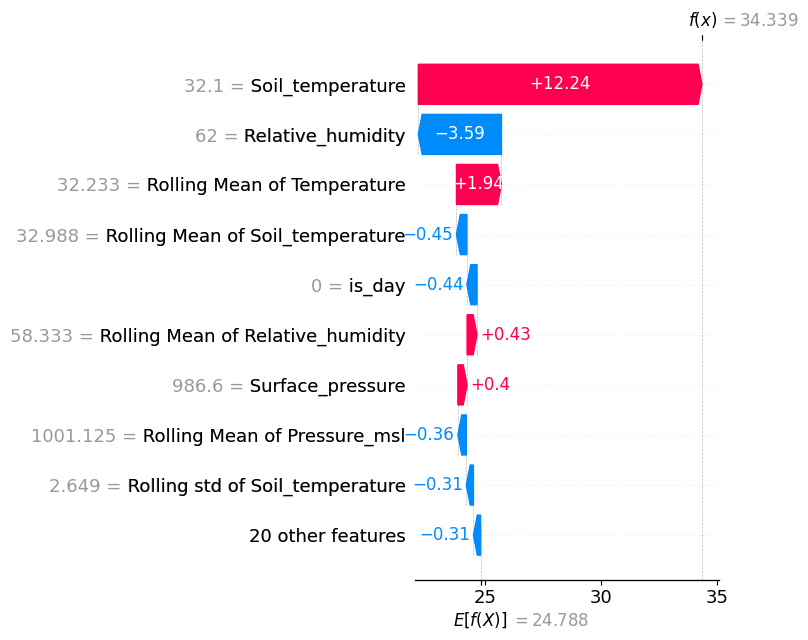

In [59]:
shap.plots.waterfall(shap_values[0],show = False)
plt.tight_layout()
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/reports/figures")
plt.savefig("Temperature_shap_summary(waterfall).png", dpi=300, bbox_inches="tight")
plt.show()

##### Soil_temperature

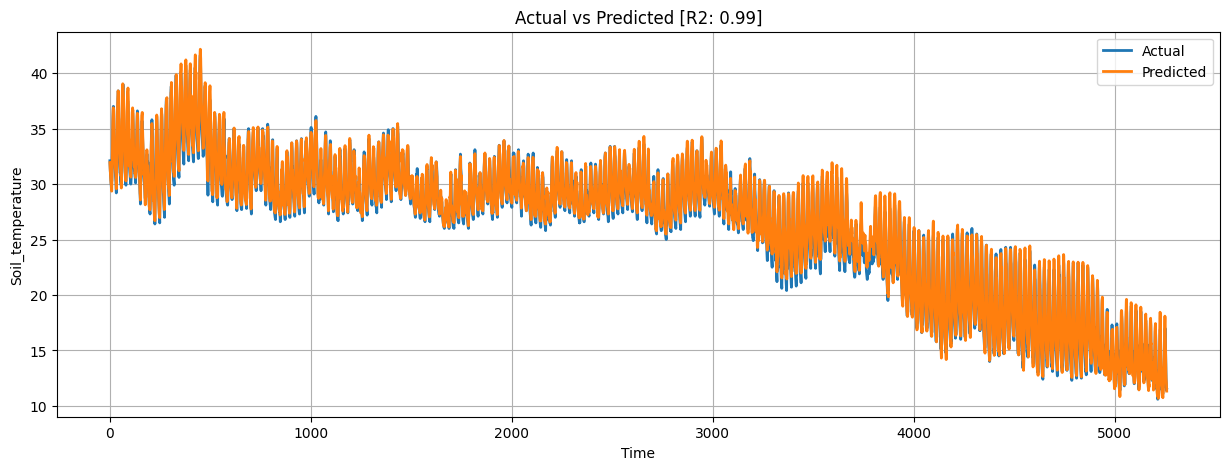

In [60]:
plot_Actual_vs_Predicted("Soil_temperature")

In [61]:
summary("Soil_temperature")

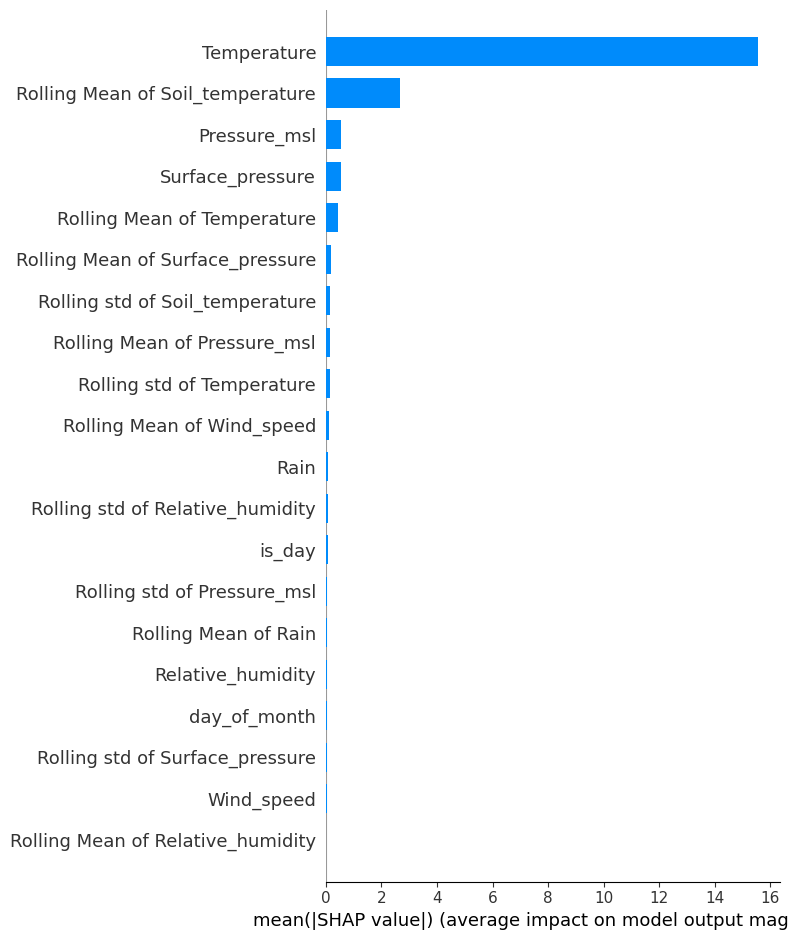

In [62]:
model_interpretation("Soil_temperature")

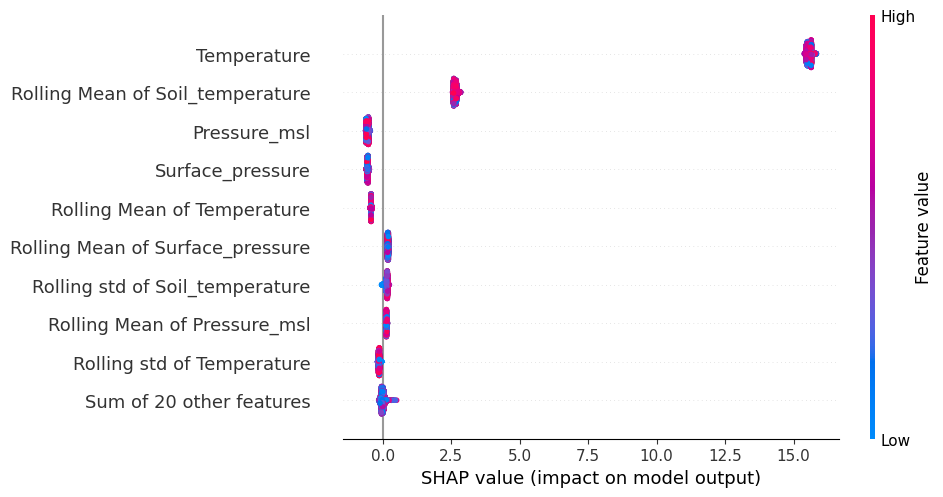

In [63]:
y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model("Soil_temperature")
explainer = shap.Explainer(model)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

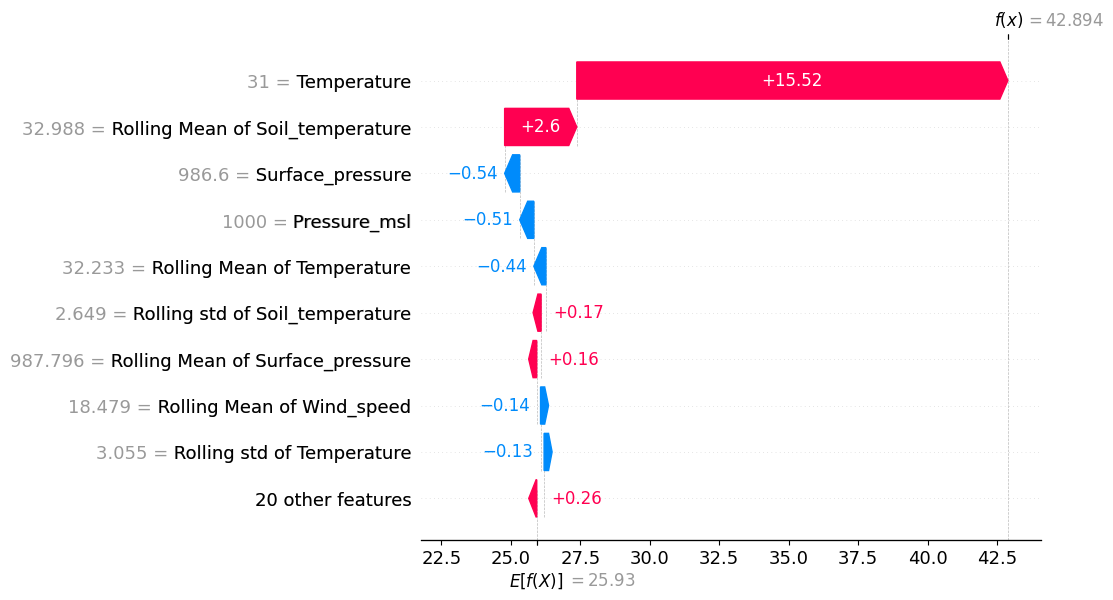

In [64]:
shap.plots.waterfall(shap_values[0])
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/reports/figures")
plt.savefig("Soil_temperature_shap_summary(waterfall).png", dpi=300, bbox_inches="tight")
plt.clf()

##### Relative_humidity

<Figure size 640x480 with 0 Axes>

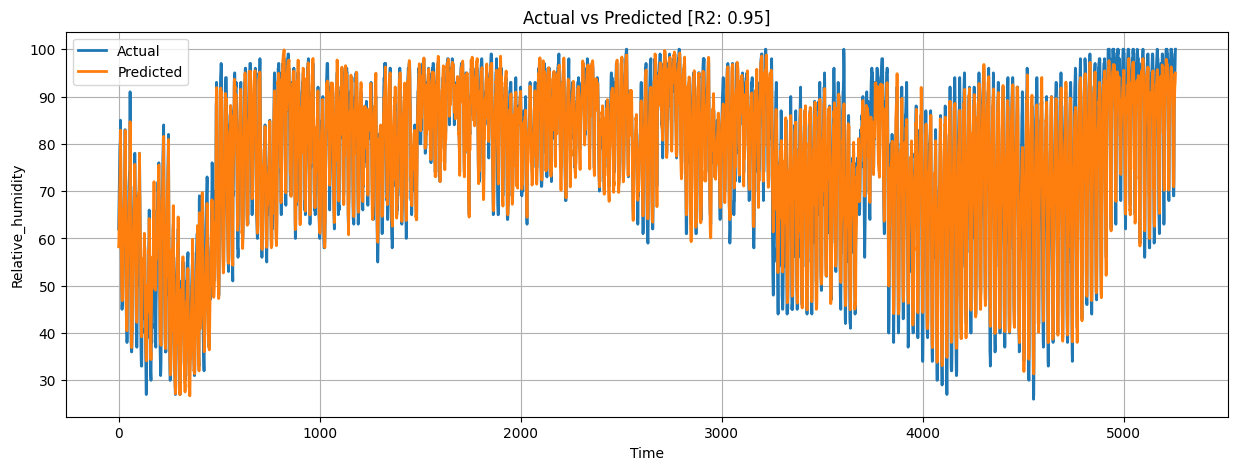

In [65]:
plot_Actual_vs_Predicted("Relative_humidity")

In [66]:
summary("Relative_humidity")

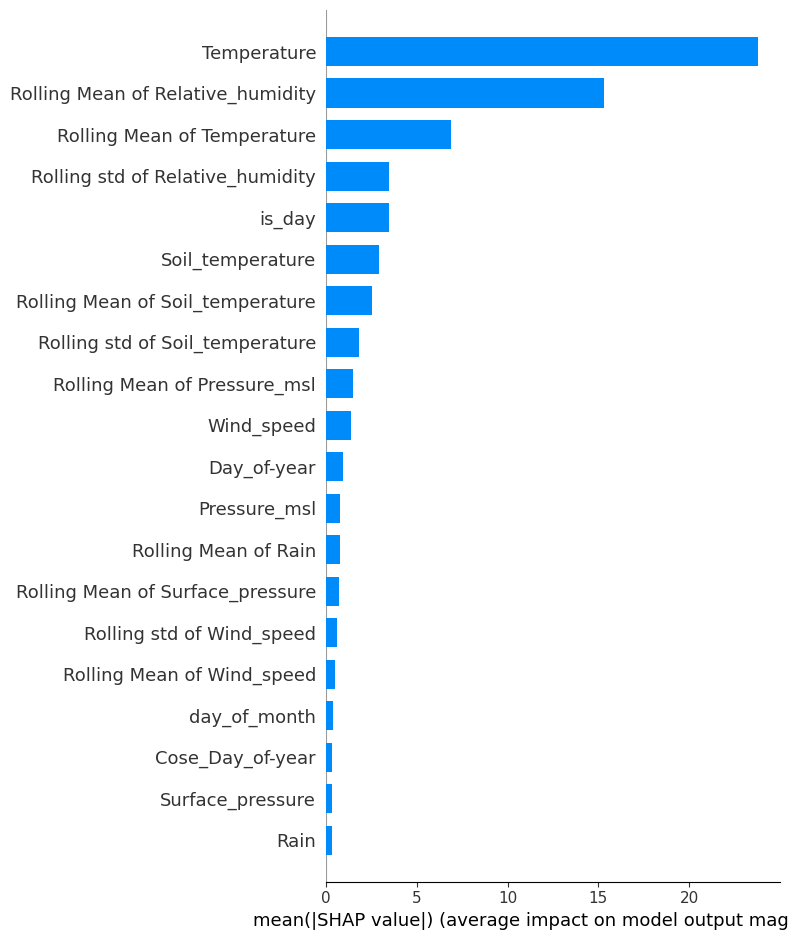

In [67]:
model_interpretation("Relative_humidity")

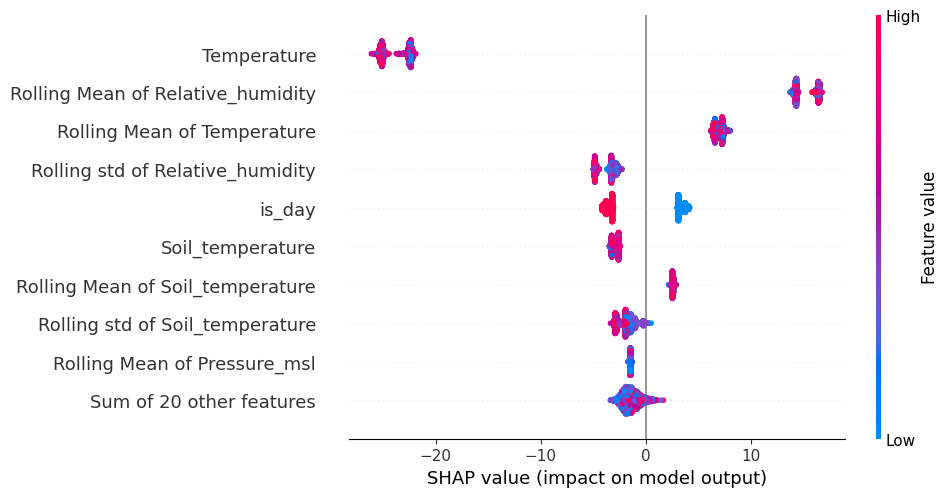

In [68]:
y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model("Relative_humidity")
explainer = shap.Explainer(model)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

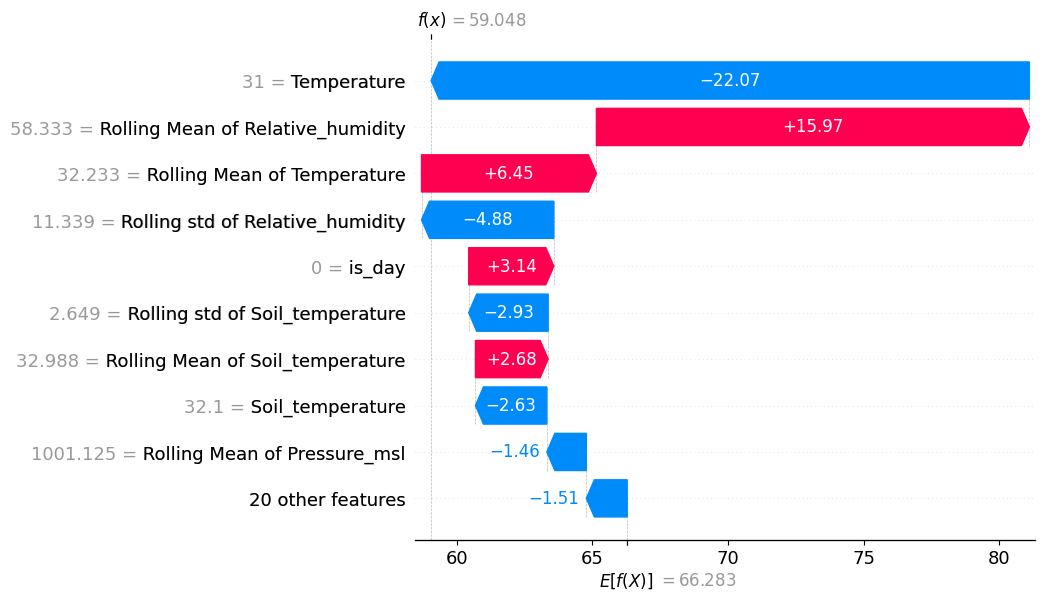

In [69]:
shap.plots.waterfall(shap_values[0],show = False)
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/reports/figures")
plt.savefig("Relative_humidity_shap_summary(waterfall).png", dpi=300, bbox_inches="tight")
plt.show()

##### Rain

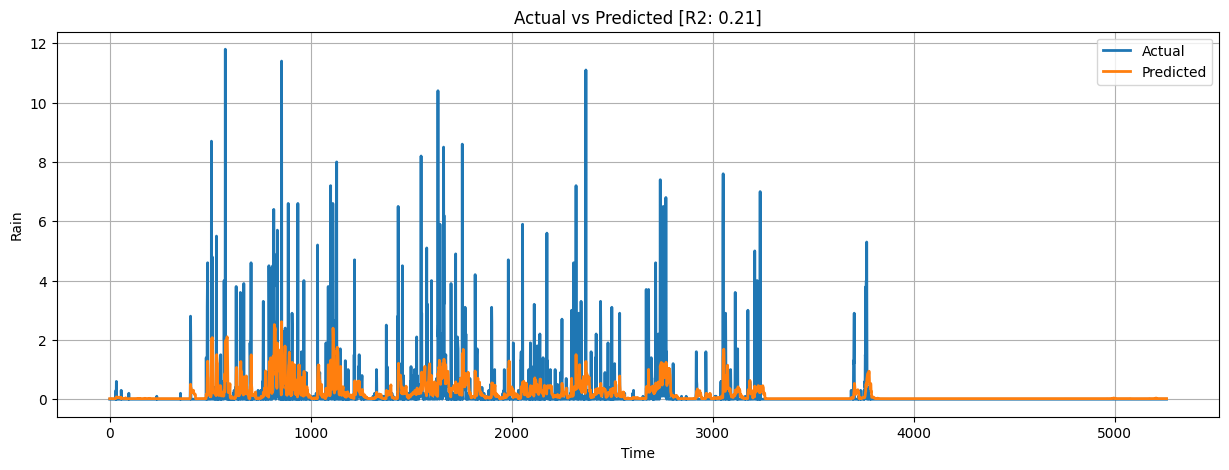

In [70]:
plot_Actual_vs_Predicted("Rain")

In [71]:
summary("Rain")

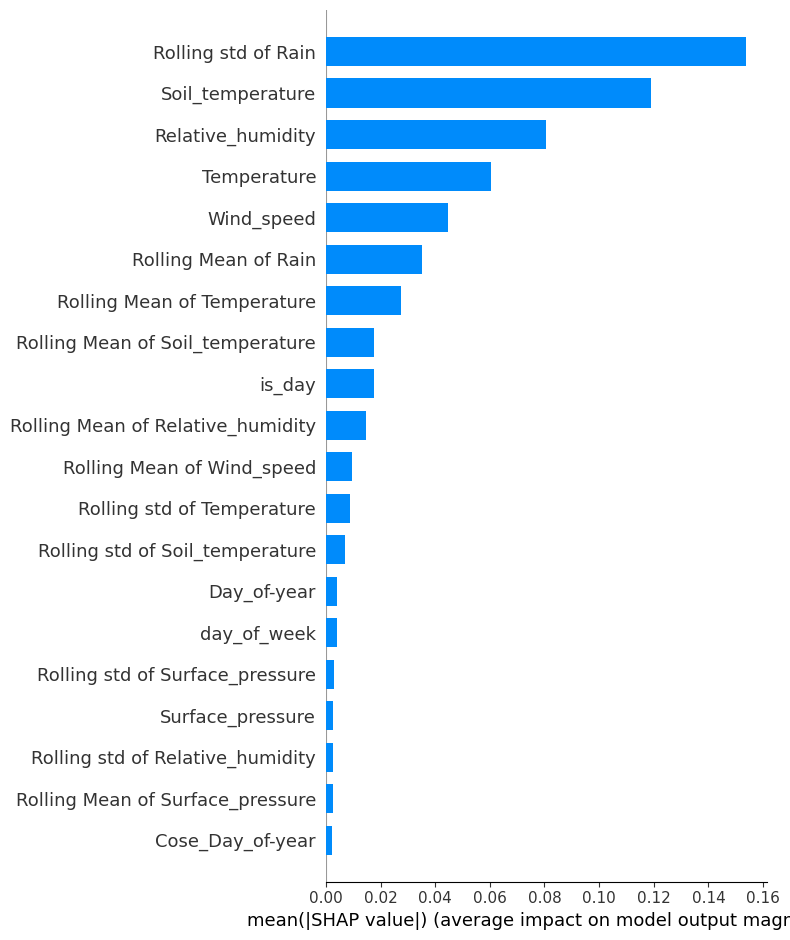

In [72]:
model_interpretation("Rain")

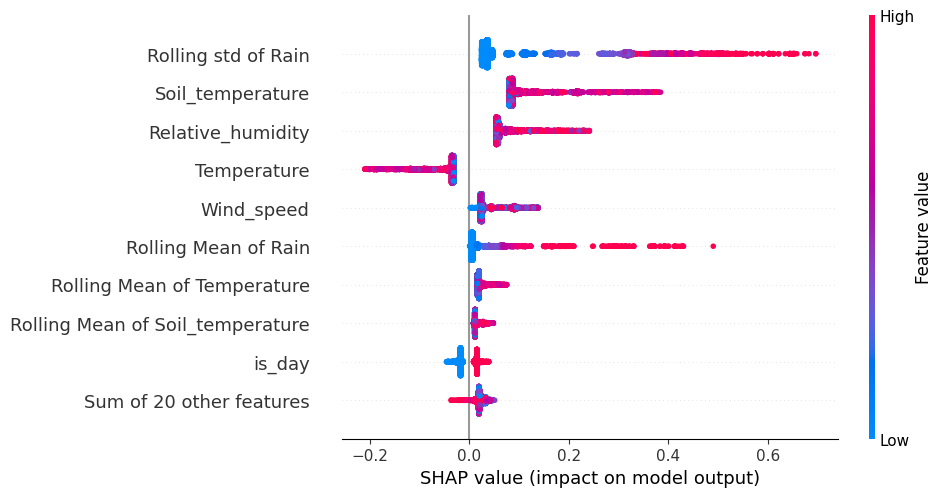

In [73]:
y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model("Rain")
explainer = shap.Explainer(model)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

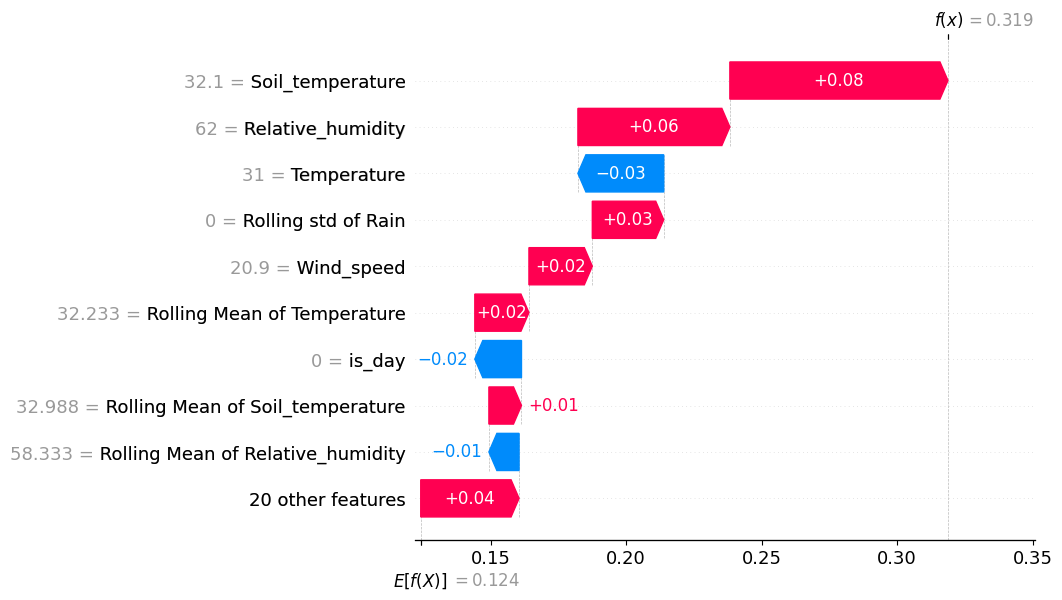

In [74]:
shap.plots.waterfall(shap_values[0],show = False)
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/reports/figures")
plt.savefig("Rain_shap_summary(waterfall).png", dpi=300, bbox_inches="tight")
plt.show()

#### Surface_pressure

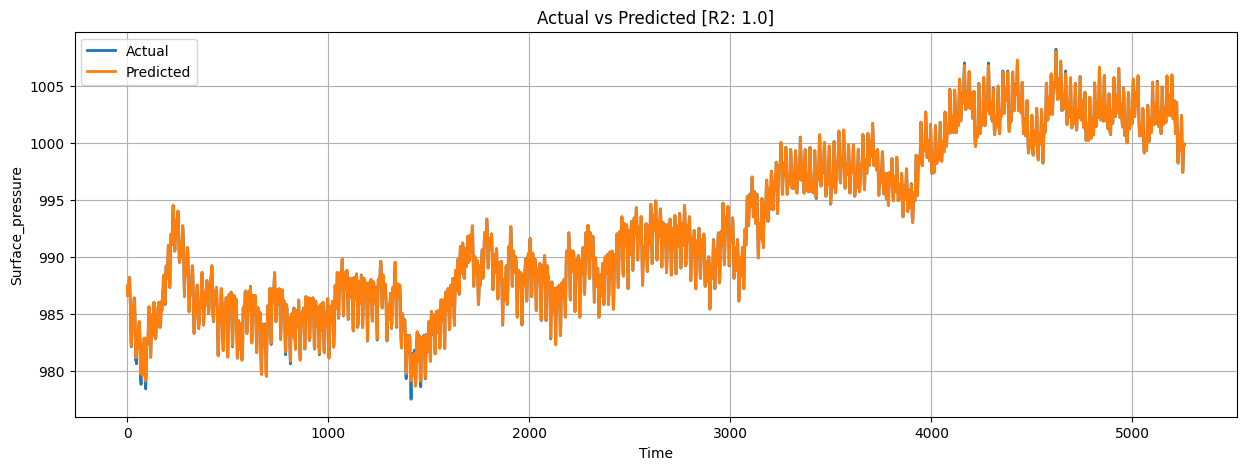

In [75]:
plot_Actual_vs_Predicted("Surface_pressure")

In [76]:
summary("Surface_pressure")

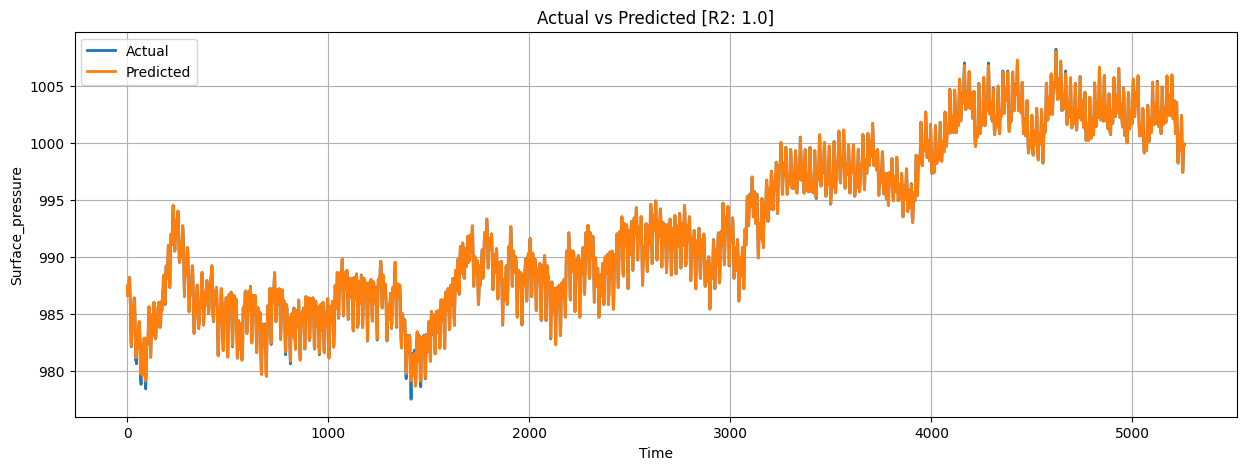

In [77]:
plot_Actual_vs_Predicted("Surface_pressure")

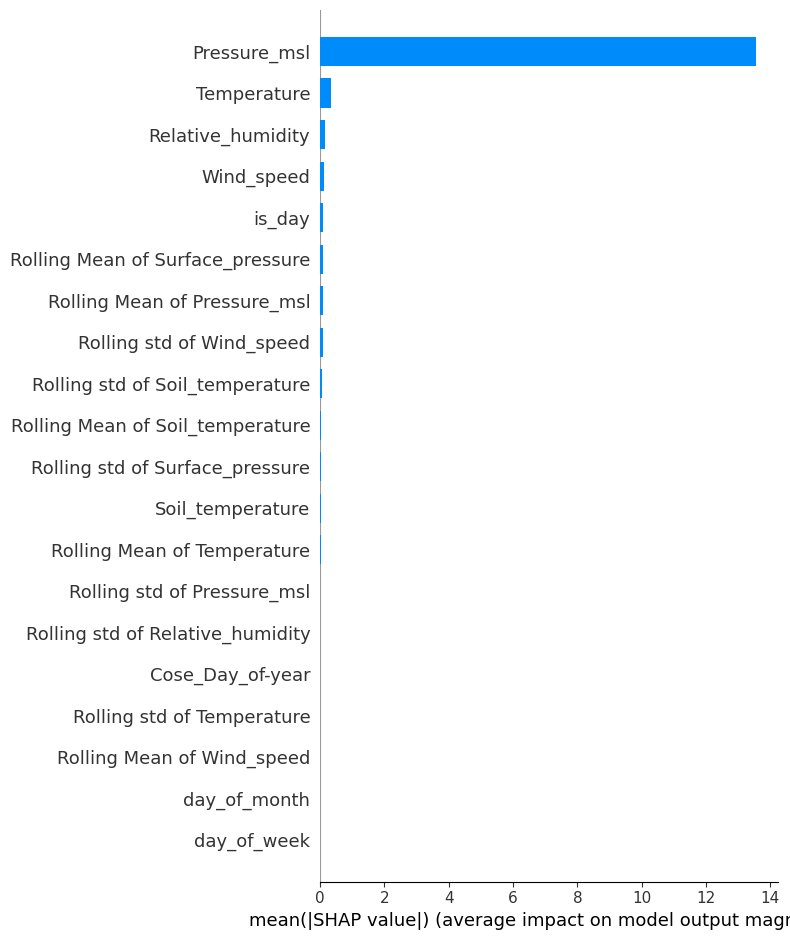

In [78]:
model_interpretation("Surface_pressure")

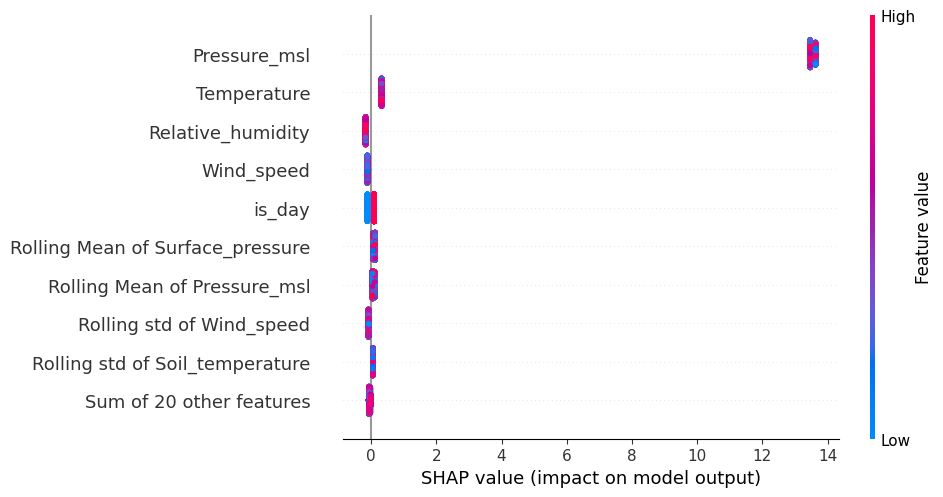

In [79]:
y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model("Surface_pressure")
explainer = shap.Explainer(model)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

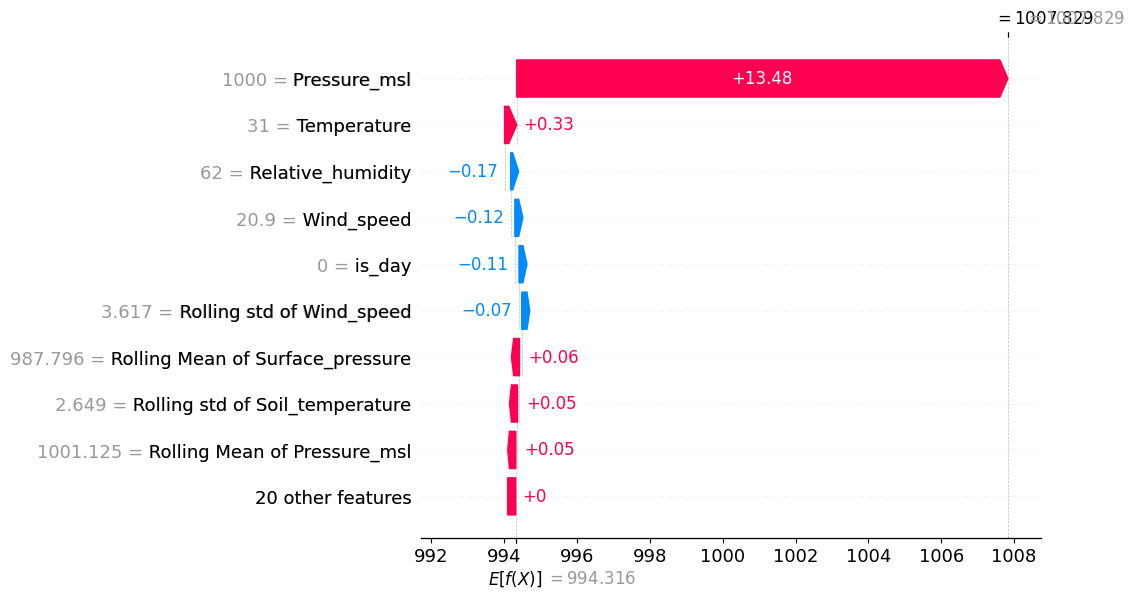

In [81]:
shap.plots.waterfall(shap_values[0],show = False)
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/reports/figures")
plt.savefig("Surface_pressure_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

#### Pressure_msl

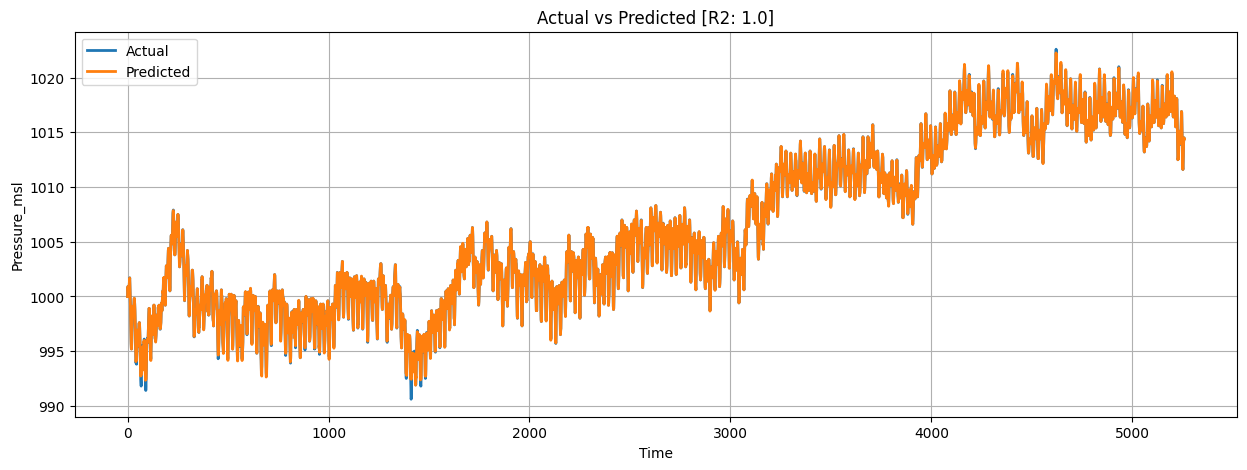

In [82]:
plot_Actual_vs_Predicted("Pressure_msl")

In [83]:
summary("Pressure_msl")

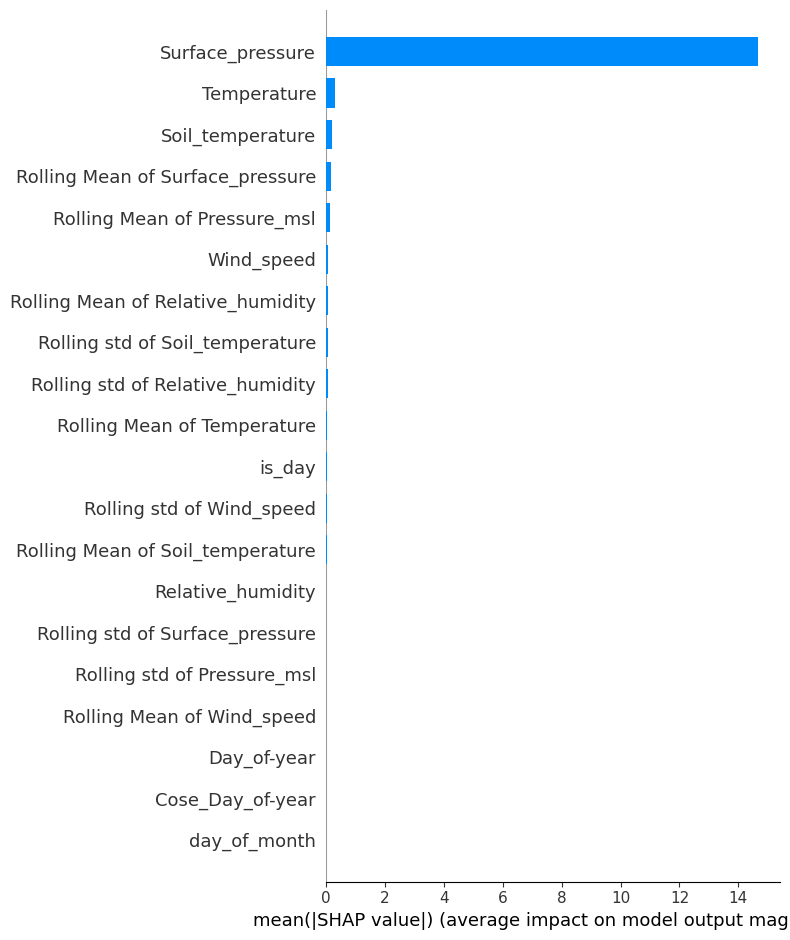

In [84]:
model_interpretation("Pressure_msl")

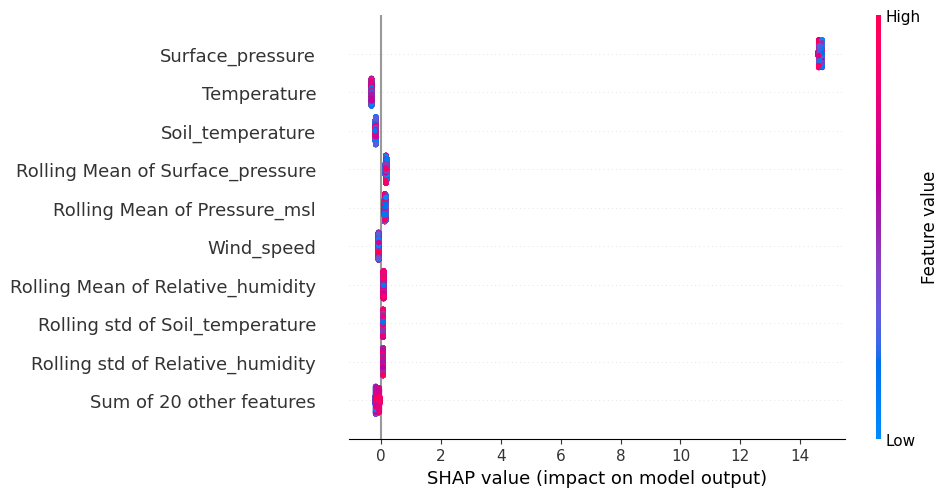

In [85]:
y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model("Pressure_msl")
explainer = shap.Explainer(model)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

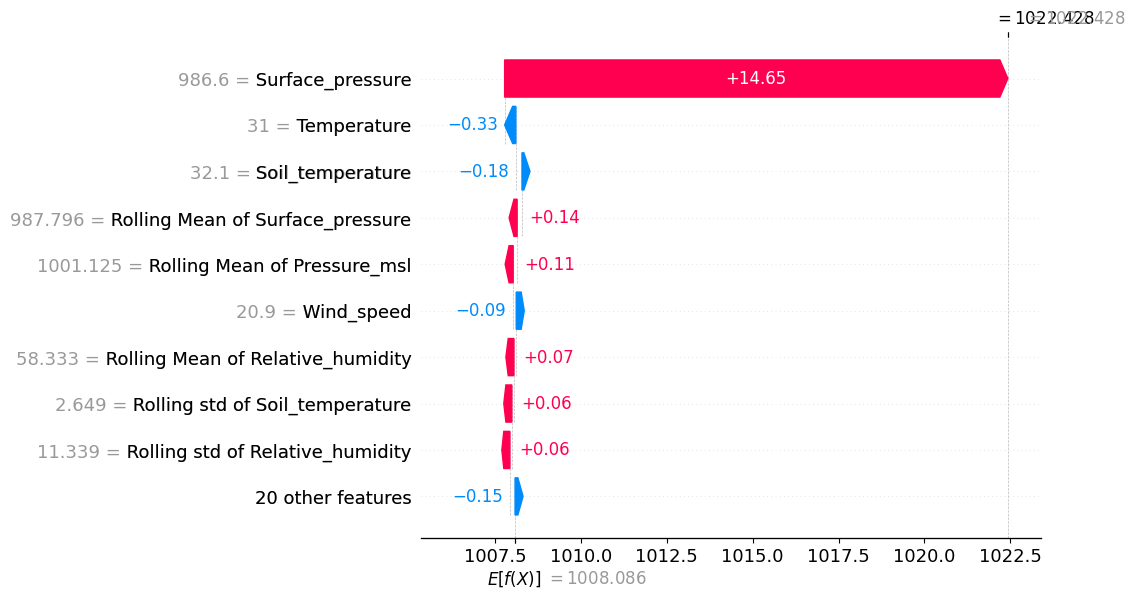

In [86]:
shap.plots.waterfall(shap_values[0],show = False)
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/reports/figures")
plt.savefig("Pressure_msl_shap_summary(waterfall).png", dpi=300, bbox_inches="tight")
plt.show()

#### is_day

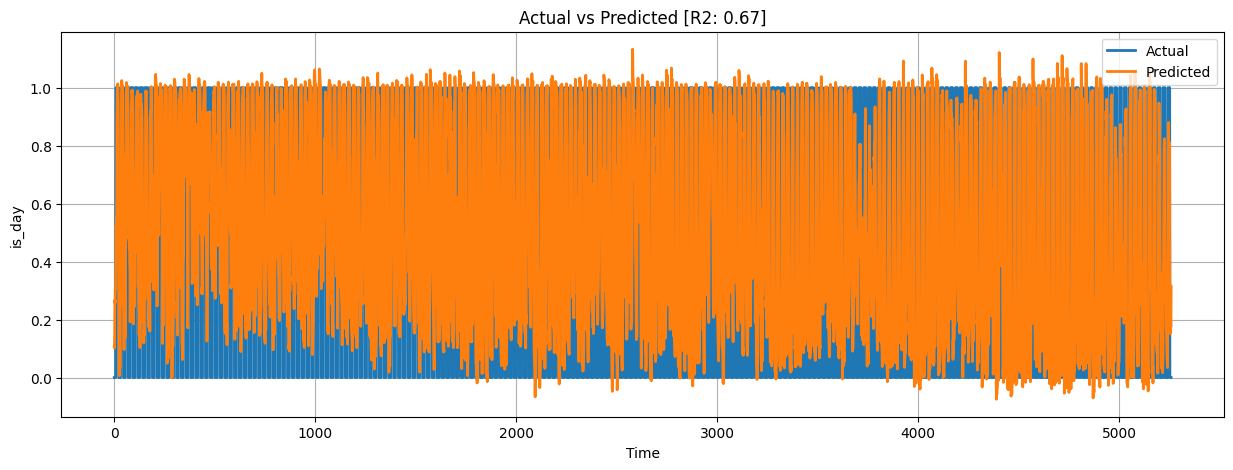

In [87]:
plot_Actual_vs_Predicted("is_day")

In [88]:
summary("is_day")

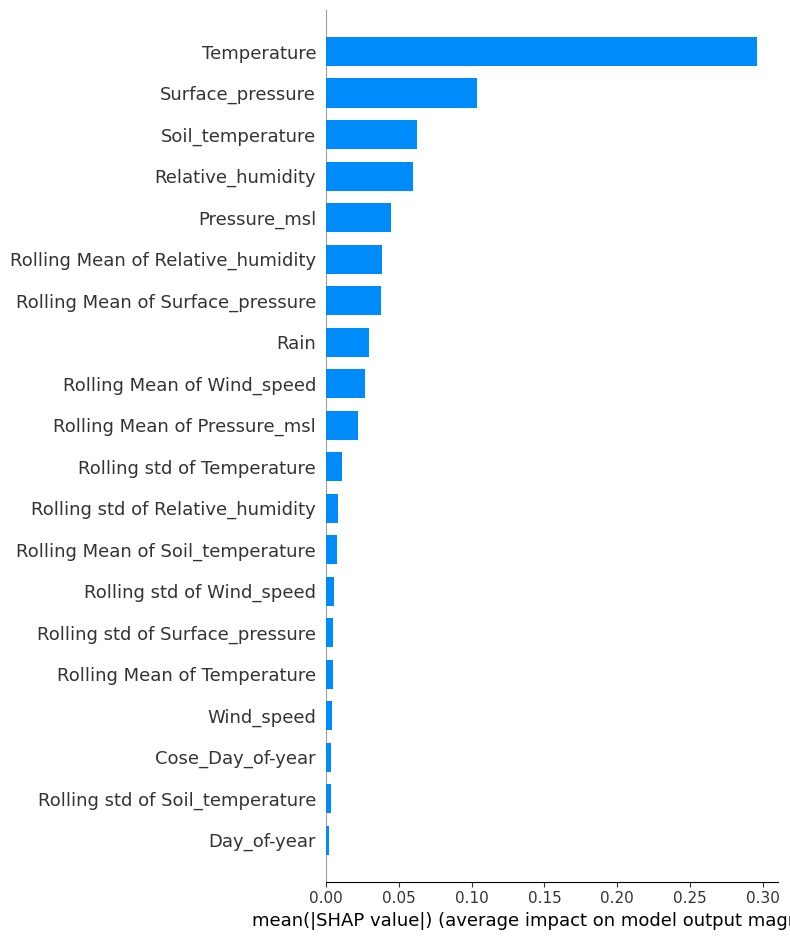

In [89]:
model_interpretation("is_day")

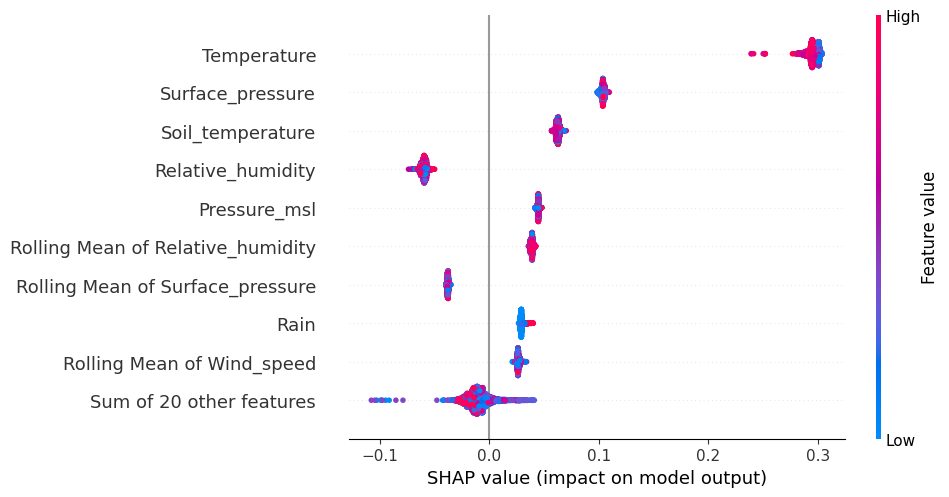

In [90]:
y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model("is_day")
explainer = shap.Explainer(model)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

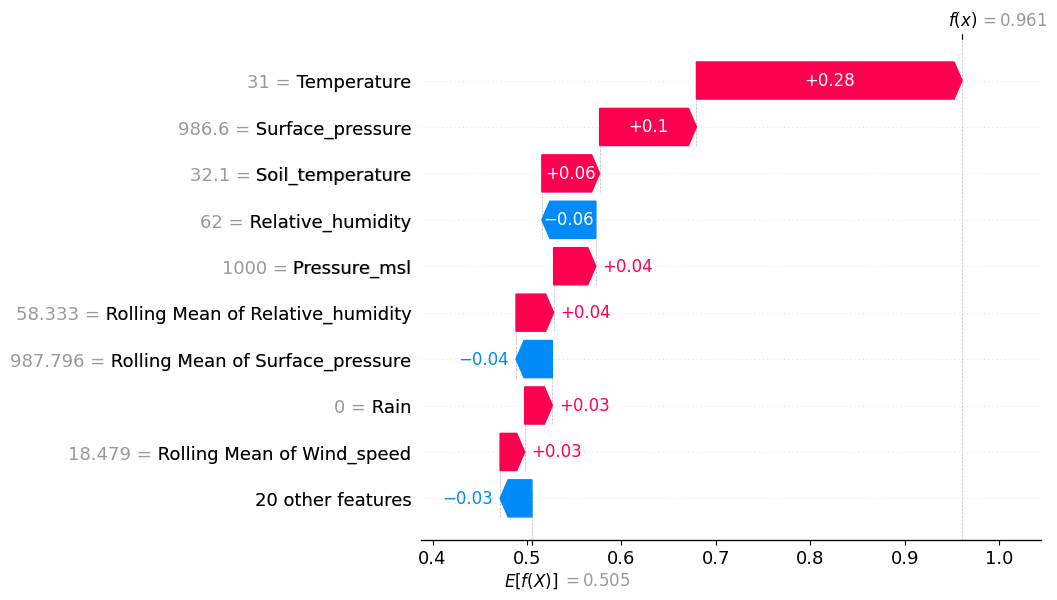

In [91]:
shap.plots.waterfall(shap_values[0],show = False)
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/reports/figures")
plt.savefig("is_day_shap_summary(waterfall).png", dpi=300, bbox_inches="tight")
plt.show()

In [92]:
cpu_percent = ps.cpu_percent(interval=1)
print(f"CPU Usage: {cpu_percent}%")

CPU Usage: 52.6%
